# Spaceship Titanic EDA

### Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset import

In [4]:
sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/train.csv')
num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']
display(df.head())
print('\n\n - DATA INFO -')
print(df.info())
display(df.describe())

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True




 - DATA INFO -
<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB
None


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


### EDA

**checking for dataset balance**

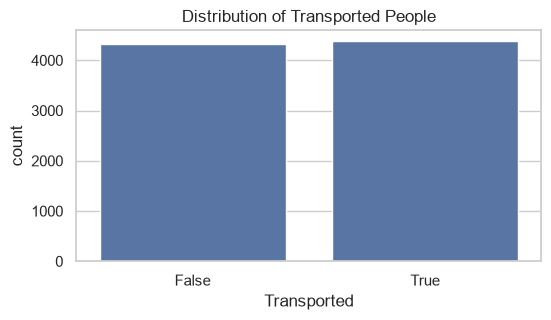

Transported
True     0.503624
False    0.496376
Name: proportion, dtype: float64


In [5]:
plt.figure(figsize=(6,3))
sns.countplot(data=df, x='Transported')
plt.title('Distribution of Transported People')
plt.show()
print(df['Transported'].value_counts(normalize=True))

**Relating categorical features to transported value**

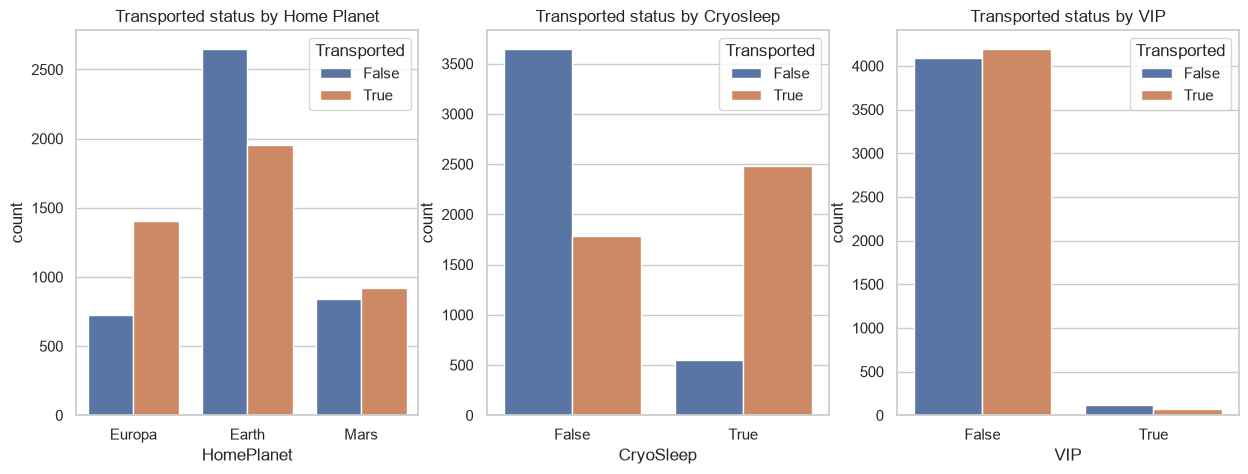

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.countplot(data=df, x='HomePlanet', hue='Transported', ax=axes[0])
axes[0].set_title('Transported status by Home Planet')

sns.countplot(data=df, x='CryoSleep', hue='Transported', ax=axes[1])
axes[1].set_title('Transported status by Cryosleep')

sns.countplot(data=df, x='VIP', hue='Transported', ax=axes[2])
axes[2].set_title('Transported status by VIP')

plt.show()

**Relating numerical features to transported value**

C:\Users\senect\AppData\Local\Temp\ipykernel_4308\107793299.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


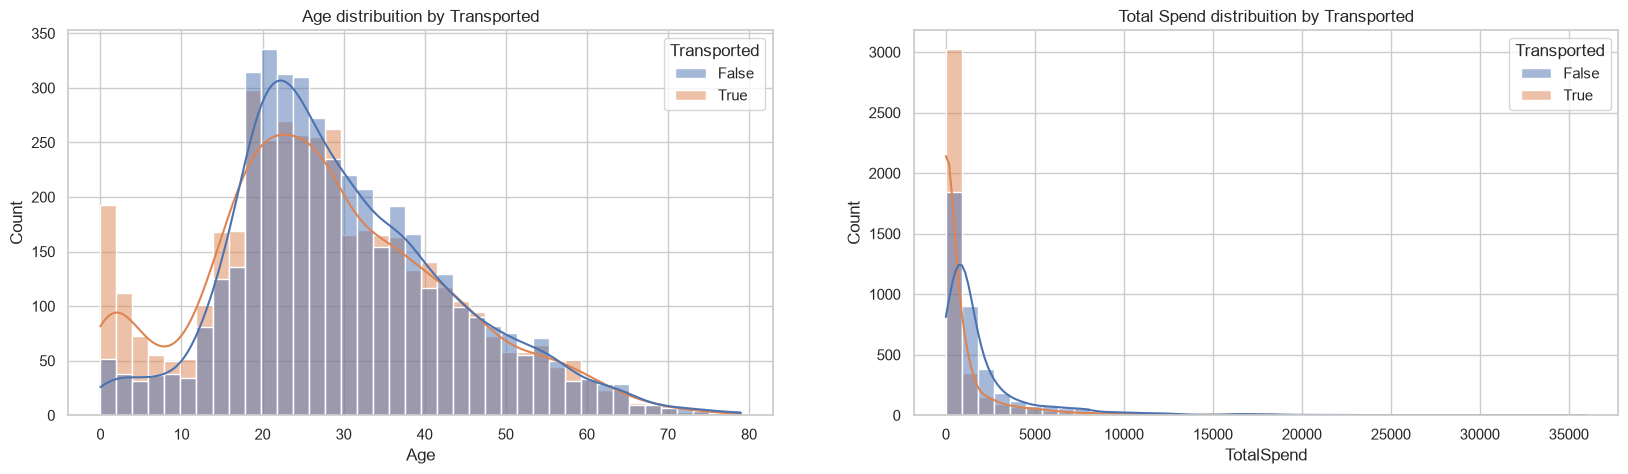

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(20,5))

sns.histplot(data=df, x='Age', hue='Transported', bins=40, kde=True, ax=axes[0])
axes[0].set_title('Age distribuition by Transported')

df['TotalSpend'] = df['RoomService'] + df['FoodCourt'] + df['ShoppingMall'] + df['Spa'] + df['VRDeck']
sns.histplot(data=df, x='TotalSpend', hue='Transported', bins=40, kde=True, ax=axes[1])
axes[1].set_title('Total Spend distribuition by Transported')

fig.show()

**Correlation Heatmap**

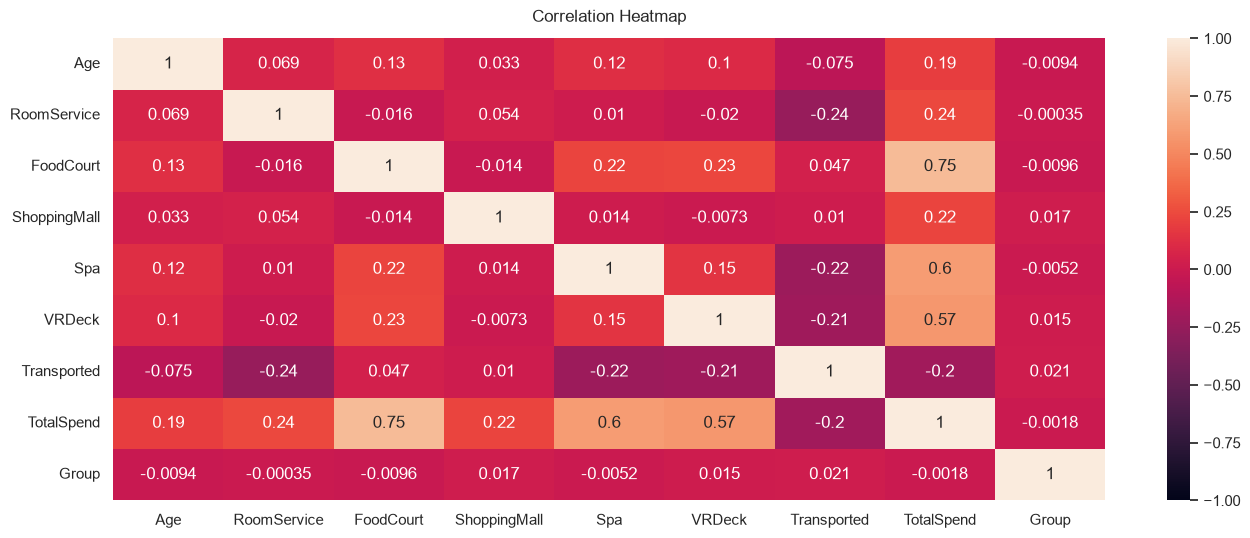

In [12]:
plt.figure(figsize=(16,6))
heatmap = sns.heatmap(df.corr(numeric_only=True), vmin=-1, vmax=1, annot=True)
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':12}, pad=12)
plt.show()